# Descriptive Statistics & Probability Distributions — Lab Notebook
### Companion code for the AI/ML B.Tech (3rd Year) Study Handbook

This notebook reproduces **every calculation and plot** from the handbook, in the same order:

1. Descriptive Statistics — Mean, Median, Variance
2. Probability Distributions — Normal, Binomial, Poisson
3. Try-it-yourself solutions

Run the cells top to bottom. Each section starts with a short markdown recap, then code.


In [1]:
# Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)
print("Libraries loaded ✔")


Libraries loaded ✔


---
## 1. Descriptive Statistics: Mean, Median, Variance

**Dataset:** Daily active users (in thousands) of an app over 5 days — the same numbers used in
the handbook's Worked Example.


In [2]:
daily_users = pd.Series([12, 15, 14, 18, 16], name="daily_users_thousands")
daily_users


0    12
1    15
2    14
3    18
4    16
Name: daily_users_thousands, dtype: int64

### 1.1 Mean — by formula, then with pandas/numpy

In [3]:
# By formula
mean_manual = sum(daily_users) / len(daily_users)
print("Mean (manual formula):", mean_manual)

# Using numpy / pandas (what you'll actually use in practice)
print("Mean (numpy):", np.mean(daily_users))
print("Mean (pandas):", daily_users.mean())


Mean (manual formula): 15.0
Mean (numpy): 15.0
Mean (pandas): 15.0


### 1.2 Median — by formula, then with pandas/numpy

In [4]:
sorted_vals = sorted(daily_users)
print("Sorted data:", sorted_vals)

median_manual = sorted_vals[len(sorted_vals)//2]  # works because n=5 is odd
print("Median (manual):", median_manual)
print("Median (numpy):", np.median(daily_users))
print("Median (pandas):", daily_users.median())


Sorted data: [12, 14, 15, 16, 18]
Median (manual): 15
Median (numpy): 15.0
Median (pandas): 15.0


### 1.3 Variance & Standard Deviation

In [5]:
# Population variance (divide by n) -- matches the handbook's worked example
pop_var = np.mean((daily_users - daily_users.mean())**2)
print("Population variance (manual):", pop_var)
print("Population variance (numpy, ddof=0):", np.var(daily_users, ddof=0))

# Sample variance (divide by n-1) -- what pandas uses by default (Bessel's correction)
print("Sample variance (pandas default):", daily_users.var())
print("Sample standard deviation (pandas default):", daily_users.std())

print("\nInterpretation: users average ~15k/day with a typical swing of ~2k (population sigma).")


Population variance (manual): 4.0
Population variance (numpy, ddof=0): 4.0
Sample variance (pandas default): 5.0
Sample standard deviation (pandas default): 2.23606797749979

Interpretation: users average ~15k/day with a typical swing of ~2k (population sigma).


### 1.4 Why the mean can mislead you — the outlier problem

**Try-it-yourself (handbook):** cart sizes for 5 users: `{3, 7, 5, 5, 100}` (the 100 might be a bot
or bulk buyer).


Mean  : 24.0
Median: 5.0


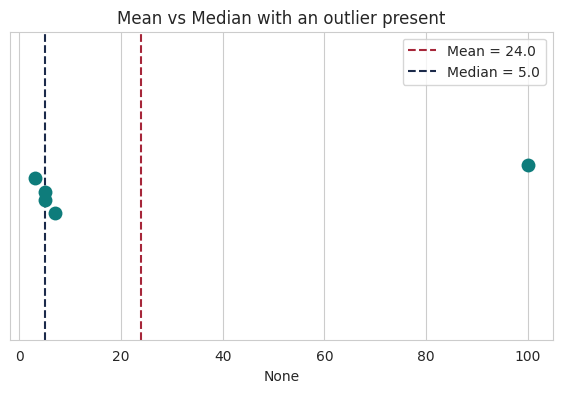


Takeaway: the median (5) reflects a 'typical' user far better than the outlier-skewed mean (24).


In [6]:
cart_sizes = pd.Series([3, 7, 5, 5, 100])
print("Mean  :", cart_sizes.mean())
print("Median:", cart_sizes.median())

fig, ax = plt.subplots()
sns.stripplot(x=cart_sizes, ax=ax, size=10, color="#0E7C7B")
ax.axvline(cart_sizes.mean(), color="#A62639", linestyle="--", label=f"Mean = {cart_sizes.mean():.1f}")
ax.axvline(cart_sizes.median(), color="#1B2A4A", linestyle="--", label=f"Median = {cart_sizes.median():.1f}")
ax.set_title("Mean vs Median with an outlier present")
ax.legend()
plt.show()

print("\nTakeaway: the median (5) reflects a 'typical' user far better than the outlier-skewed mean (24).")


### 1.5 AI/ML tie-in — `StandardScaler` vs `RobustScaler`

This is exactly why scikit-learn offers two different scalers: one built on the mean/variance,
one built on the median/IQR.


In [7]:
from sklearn.preprocessing import StandardScaler, RobustScaler

X = cart_sizes.values.reshape(-1, 1)

standard_scaled = StandardScaler().fit_transform(X).ravel()
robust_scaled   = RobustScaler().fit_transform(X).ravel()

comparison = pd.DataFrame({
    "raw": cart_sizes,
    "StandardScaler (mean/std)": standard_scaled.round(2),
    "RobustScaler (median/IQR)": robust_scaled.round(2)
})
comparison


,raw,StandardScaler (mean/std),RobustScaler (median/IQR)
0,3,-0.55,-1.0
1,7,-0.45,1.0
2,5,-0.50,0.0
3,5,-0.50,0.0
4,100,2.00,47.5


Notice how the outlier (100) dominates the `StandardScaler` output — every other point gets
squashed close to zero — while `RobustScaler` keeps the four normal users spread out sensibly.
This is the direct, practical payoff of understanding mean vs. median vs. variance.


### 1.6 AI/ML tie-in — Variance and PCA (feature selection intuition)

A feature with near-zero variance carries almost no information. Let's simulate a tiny "dataset"
with one informative feature and one useless (near-constant) feature.


In [8]:
np.random.seed(1)
n = 200
informative_feature = np.random.normal(loc=50, scale=15, size=n)      # real signal, high variance
useless_feature      = np.random.normal(loc=5, scale=0.01, size=n)    # basically constant

df_features = pd.DataFrame({
    "informative_feature": informative_feature,
    "useless_feature": useless_feature
})

print(df_features.var())

from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.05)
kept = selector.fit_transform(df_features)
print("\nColumns kept after VarianceThreshold:", df_features.columns[selector.get_support()].tolist())


informative_feature    187.277719
useless_feature          0.000108
dtype: float64



Columns kept after VarianceThreshold: ['informative_feature']


---
## 2. Probability Distributions: Normal, Binomial, Poisson


### 2.1 Normal Distribution

Model residual errors: $\mu = 0,\ \sigma = 2$. We check the 68–95–99.7 rule and reproduce the
handbook's worked example (probability of `|error| > 4`).


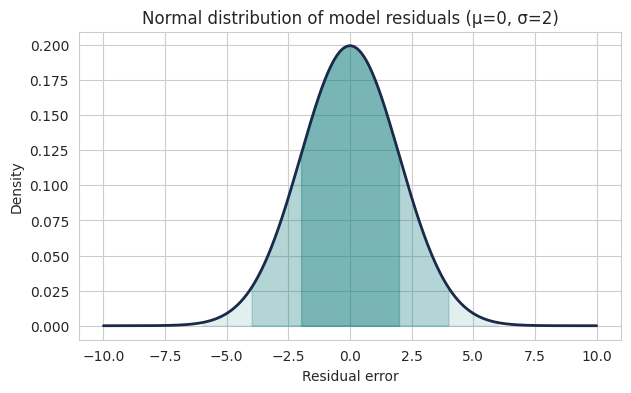

P(|error| > 4) = 0.0455  (handbook estimate was ~0.05)


In [9]:
mu, sigma = 0, 2
x = np.linspace(-10, 10, 500)
pdf = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots()
ax.plot(x, pdf, color="#1B2A4A", lw=2)
for k, alpha in zip([1, 2, 3], [0.35, 0.22, 0.12]):
    ax.fill_between(x, pdf, where=(np.abs(x - mu) <= k*sigma), color="#0E7C7B", alpha=alpha)
ax.set_title("Normal distribution of model residuals (μ=0, σ=2)")
ax.set_xlabel("Residual error"); ax.set_ylabel("Density")
plt.show()

# Handbook worked example: P(|error| > 4)
p_within_2sigma = stats.norm.cdf(4, mu, sigma) - stats.norm.cdf(-4, mu, sigma)
p_beyond = 1 - p_within_2sigma
print(f"P(|error| > 4) = {p_beyond:.4f}  (handbook estimate was ~0.05)")


**AI/ML tie-in — Z-score anomaly detection.** Flag any residual beyond 3σ as a potential
anomaly.

In [10]:
np.random.seed(7)
residuals = np.random.normal(mu, sigma, 300)
z_scores = (residuals - residuals.mean()) / residuals.std()
anomalies = residuals[np.abs(z_scores) > 3]
print(f"Detected {len(anomalies)} anomalies out of {len(residuals)} residuals (|z| > 3).")


Detected 0 anomalies out of 300 residuals (|z| > 3).


### 2.2 Binomial Distribution

Spam classifier: $p = 0.9$ correct-detection probability, $n = 10$ spam emails. Handbook asks for
$P(X = 8)$.


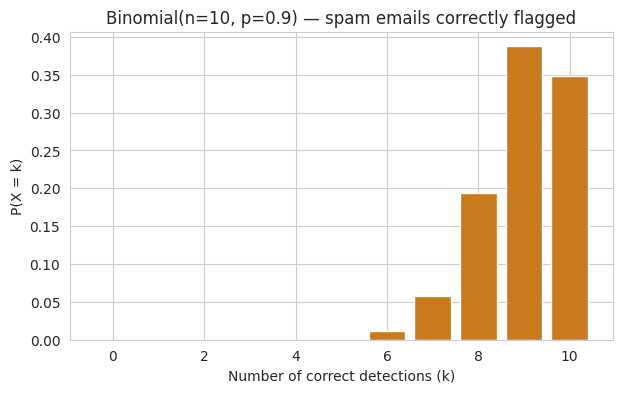

P(X = 8) = 0.1937  (handbook estimate was ~0.194)


In [11]:
n, p = 10, 0.9
k_vals = np.arange(0, n+1)
pmf = stats.binom.pmf(k_vals, n, p)

fig, ax = plt.subplots()
ax.bar(k_vals, pmf, color="#C97A1D")
ax.set_title(f"Binomial(n={n}, p={p}) — spam emails correctly flagged")
ax.set_xlabel("Number of correct detections (k)"); ax.set_ylabel("P(X = k)")
plt.show()

p_exactly_8 = stats.binom.pmf(8, n, p)
print(f"P(X = 8) = {p_exactly_8:.4f}  (handbook estimate was ~0.194)")


**AI/ML tie-in — A/B testing simulation.** Simulate 15 users seeing a new UI with a
historical 25% "Buy Now" click rate (this is also the answer to Try-it-yourself part (a):
Binomial(n=15, p=0.25)).

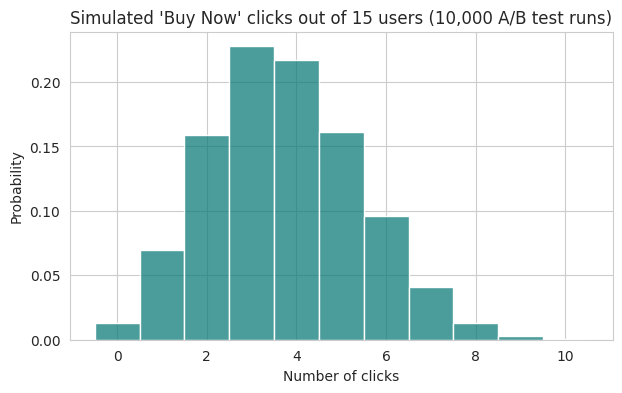

Most likely number of clicks: 3


In [12]:
n_users, click_p = 15, 0.25
simulated_click_counts = np.random.binomial(n_users, click_p, size=10000)

fig, ax = plt.subplots()
sns.histplot(simulated_click_counts, discrete=True, stat="probability", color="#0E7C7B", ax=ax)
ax.set_title(f"Simulated 'Buy Now' clicks out of {n_users} users (10,000 A/B test runs)")
ax.set_xlabel("Number of clicks")
plt.show()

print("Most likely number of clicks:", np.bincount(simulated_click_counts).argmax())


### 2.3 Poisson Distribution

Failed logins: average $\lambda = 4$ per minute. Handbook asks for $P(X = 10)$ — a possible
brute-force attack signal.


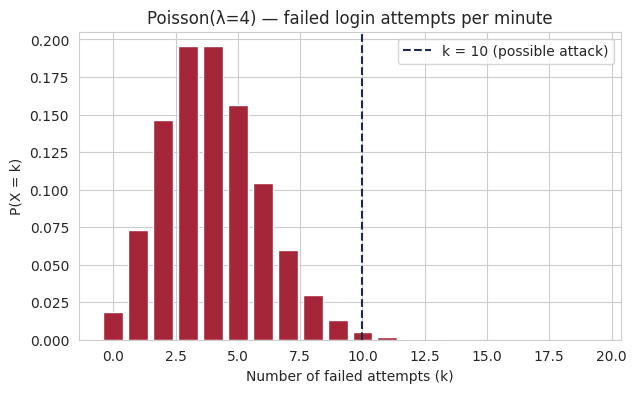

P(X = 10) = 0.0053  (handbook estimate was ~0.0053)


In [13]:
lam = 4
k_vals = np.arange(0, 20)
pmf = stats.poisson.pmf(k_vals, lam)

fig, ax = plt.subplots()
ax.bar(k_vals, pmf, color="#A62639")
ax.axvline(10, color="#1B2A4A", linestyle="--", label="k = 10 (possible attack)")
ax.set_title(f"Poisson(λ={lam}) — failed login attempts per minute")
ax.set_xlabel("Number of failed attempts (k)"); ax.set_ylabel("P(X = k)")
ax.legend()
plt.show()

p_exactly_10 = stats.poisson.pmf(10, lam)
print(f"P(X = 10) = {p_exactly_10:.4f}  (handbook estimate was ~0.0053)")


**AI/ML tie-in — setting a monitoring threshold.** Find the smallest `k` such that
`P(X >= k)` drops below 1%, i.e. a sensible alert threshold for a security dashboard.

In [14]:
threshold = None
for k in range(0, 25):
    p_at_least_k = 1 - stats.poisson.cdf(k - 1, lam)
    if p_at_least_k < 0.01:
        threshold = k
        break

print(f"Alert threshold: flag any minute with >= {threshold} failed logins "
      f"(P >= threshold is only {1 - stats.poisson.cdf(threshold-1, lam):.4f}).")


Alert threshold: flag any minute with >= 10 failed logins (P >= threshold is only 0.0081).


**Try-it-yourself part (b) answer:** a support ticketing system averaging 3 tickets/hour is
modelled with **Poisson(λ = 3)** — number of rare events (tickets) in a fixed time window (1 hour).

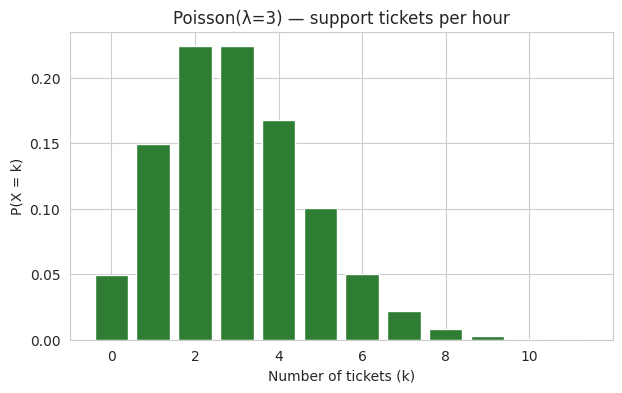

In [15]:
lam_tickets = 3
k_vals = np.arange(0, 12)
pmf_tickets = stats.poisson.pmf(k_vals, lam_tickets)

fig, ax = plt.subplots()
ax.bar(k_vals, pmf_tickets, color="#2E7D32")
ax.set_title(f"Poisson(λ={lam_tickets}) — support tickets per hour")
ax.set_xlabel("Number of tickets (k)"); ax.set_ylabel("P(X = k)")
plt.show()


---
## 3. Practice Question Solutions (code-checkable)

Use these cells to verify your hand-worked answers to the handbook's Practice Questions.


**Q1 — mean vs. median with an outlier score of 100:**

In [16]:
scores = pd.Series([55, 60, 62, 58, 100, 61, 59])
print("Mean  :", scores.mean())
print("Median:", scores.median())
print("-> The median better represents a 'typical' score; the 100 pulls the mean up.")


Mean  : 65.0
Median: 60.0
-> The median better represents a 'typical' score; the 100 pulls the mean up.


**Q3 — normal residuals, μ=0, σ=5: fraction with |residual| > 15 (i.e. beyond 3σ):**

In [17]:
mu3, sigma3 = 0, 5
p3 = 1 - (stats.norm.cdf(15, mu3, sigma3) - stats.norm.cdf(-15, mu3, sigma3))
print(f"P(|residual| > 15) = {p3:.4f}  (~0.3%, matching the 68-95-99.7 rule's 3-sigma tail)")


P(|residual| > 15) = 0.0027  (~0.3%, matching the 68-95-99.7 rule's 3-sigma tail)


**Q4 — CTR 12%, 25 impressions, exactly 3 clicks (Binomial):**

In [18]:
p4 = stats.binom.pmf(3, n=25, p=0.12)
print(f"P(X = 3) = {p4:.4f}")


P(X = 3) = 0.2387


**Q5 — IoT sensor averages 2 alerts/hour; P(5 or more alerts) (Poisson):**

In [19]:
lam5 = 2
p5 = 1 - stats.poisson.cdf(4, lam5)  # P(X >= 5) = 1 - P(X <= 4)
print(f"P(X >= 5) = {p5:.4f}")


P(X >= 5) = 0.0527


---
## Summary

| Concept | `numpy`/`pandas`/`scipy` call | Typical AI/ML use |
|---|---|---|
| Mean | `np.mean()`, `.mean()` | `StandardScaler`, MSE loss, baseline model |
| Median | `np.median()`, `.median()` | `RobustScaler`, robust imputation |
| Variance | `np.var()`, `.var()` | `VarianceThreshold`, PCA, bias-variance tradeoff |
| Normal | `scipy.stats.norm` | Gaussian Naive Bayes, residual checks, z-score anomaly detection |
| Binomial | `scipy.stats.binom` | A/B testing, ensemble accuracy, Bernoulli NB |
| Poisson | `scipy.stats.poisson` | Traffic/request modelling, fraud/anomaly thresholds, Poisson regression |

Go back to the handbook for the full derivations, callout boxes, and additional practice
questions.
